## Data Cleaning Notebook

**Preparing the data so that it can be used to generate momentum, mean-reversion and breakout signals**

In [2]:
import os
print(os.getcwd())

C:\Users\Aksha\OneDrive\Documents\GitHub\systematic-alpha-research\01_data-cleaning


In [3]:
# Importing the data into the notebook
import pandas as pd

futures_df = pd.read_excel("C:/Users/Aksha/OneDrive/Documents/GitHub/systematic-alpha-research/01_data-cleaning/Signal_Project_Data.xlsx", sheet_name = "Data")
futures_df = futures_df.rename(columns={"index":"Date"})
futures_df.head()

,Date,EDOLLAR,SP500,US10,LEANHOG,JPY,GOLD,WHEAT,NIKKEI,COPPER,BITCOIN
0,1984-03-23,71.84001,464.55,-33.070302,-5.24,0.012126,1145.9,857.50,NaN,NaN,NaN
1,1984-03-26,71.91001,464.65,-32.914052,-5.36,0.012139,1147.6,860.50,NaN,NaN,NaN
2,1984-03-27,71.89001,465.45,-32.976552,-4.79,0.012140,1146.4,859.75,NaN,NaN,NaN
3,1984-03-28,71.89001,467.70,-32.632802,-4.44,0.012153,1149.4,857.50,NaN,NaN,NaN
4,1984-03-29,71.86001,466.40,-32.445302,-4.56,0.012147,1148.9,858.25,NaN,NaN,NaN


### Investigating Chronology:

In [4]:
# Understanding the structure of the data frame.
futures_df.info()
print("\nStart:", futures_df["Date"].min(), " End:", futures_df["Date"].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10116 entries, 0 to 10115
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     10116 non-null  datetime64[ns]
 1   EDOLLAR  10116 non-null  float64       
 2   SP500    10116 non-null  float64       
 3   US10     10116 non-null  float64       
 4   LEANHOG  10116 non-null  float64       
 5   JPY      10116 non-null  float64       
 6   GOLD     10116 non-null  float64       
 7   WHEAT    10116 non-null  float64       
 8   NIKKEI   3016 non-null   float64       
 9   COPPER   7131 non-null   float64       
 10  BITCOIN  1309 non-null   float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 869.5 KB

Start: 1984-03-23 00:00:00  End: 2022-12-30 00:00:00


In [5]:
# Inspecting the chronology of the dates.
print("Monotonic increasing:", futures_df["Date"].is_monotonic_increasing)
print("Duplicate dates:", futures_df["Date"].duplicated().sum())
gaps = futures_df["Date"].diff().dt.days
print("Max gap between rows (days):", gaps.max())
print("Number of gaps > 4 days:", (gaps > 4).sum())

Monotonic increasing: True
Duplicate dates: 0
Max gap between rows (days): 3.0
Number of gaps > 4 days: 0


In [6]:
# NIKKEI, COPPER and BITCOIn have fewer entries; testing whether the fewer entries means there are holes in the data or start at a later date.

for col in ["NIKKEI", "COPPER", "BITCOIN"]:
    s = futures_df[col]
    first_valid = s.first_valid_index()
    last_valid = s.last_valid_index()
    
    internal_gaps = s.loc[first_valid:last_valid].isna().sum()
    print(col,
          "| starts:", futures_df["Date"].iloc[first_valid].date(),
          "| ends:", futures_df["Date"].iloc[last_valid].date(),
          "| internal gaps:", internal_gaps)

NIKKEI | starts: 2011-06-10 | ends: 2022-12-30 | internal gaps: 0
COPPER | starts: 1995-09-01 | ends: 2022-12-30 | internal gaps: 0
BITCOIN | starts: 2017-12-26 | ends: 2022-12-30 | internal gaps: 0


## Chronology Findings:

I have found that NIKKEI, COPPER and BITCOIN all have shorter market runs compared to the remaining assets but at the time, I was unsure as to whether the this meant there were gaps in the data. I know that the dates were consecutive and consistent with no duplicates so I tested whether there were any internal gaps in the data for the shorter runs. If there were, this would have led to problems in the day to day volatility calculations which would affect the signal generation. However, I found this not to be a problem as there were no internal gaps in the data.

## Investigating Stale Runs:

In [7]:
# Identifying Stale Data

import itertools

for col in futures_df.columns[1:]:  # skip 'Date'
    s = futures_df[col].dropna()
    is_same_as_prev = s.diff().eq(0)   # True where today's price == yesterday's

    run_lengths = []
    for k, g in itertools.groupby(is_same_as_prev):     # k will only be True or False, g will form a list of each group of True and False
        if k:                      # only focuses on True - where the previous price is the same as today's price
            run_lengths.append(len(list(g)))
    longest = max(run_lengths, default=0)
    print(col, "| longest stuck-price run (days):", longest)

EDOLLAR | longest stuck-price run (days): 7
SP500 | longest stuck-price run (days): 6
US10 | longest stuck-price run (days): 4
LEANHOG | longest stuck-price run (days): 6
JPY | longest stuck-price run (days): 6
GOLD | longest stuck-price run (days): 6
WHEAT | longest stuck-price run (days): 3
NIKKEI | longest stuck-price run (days): 29
COPPER | longest stuck-price run (days): 4
BITCOIN | longest stuck-price run (days): 11


In [8]:
for col in futures_df.columns[1:]:
    s = futures_df[col].dropna()
    is_same_as_prev = s.diff().eq(0)
    
    # tag each consecutive run with a group id
    group_id = (is_same_as_prev != is_same_as_prev.shift()).cumsum()
    
    # for stale runs only, find their length and where they start/end
    stale_runs = (
        futures_df.loc[s.index]
        .assign(group_id=group_id, stuck=is_same_as_prev)
        .query("stuck == True")
        .groupby("group_id")
        .agg(start=("Date", "first"), end=("Date", "last"), length=("Date", "size"), price=(col, "first"))
    )
    
    long_runs = stale_runs.query("length >= 5")   # flag anything 5+ days flat
    if len(long_runs) > 0:
        print(f"--- {col} ---")
        print(long_runs.to_string())

--- EDOLLAR ---
              start        end  length     price
group_id                                        
1378     2015-10-22 2015-10-30       7  97.09501
--- SP500 ---
              start        end  length   price
group_id                                      
790      2014-07-29 2014-08-05       6  1875.0
--- LEANHOG ---
              start        end  length   price
group_id                                      
252      1991-05-21 1991-05-27       5  29.870
256      1991-06-10 1991-06-14       5  29.170
1258     2019-02-15 2019-02-22       6  97.555
--- JPY ---
              start        end  length     price
group_id                                        
810      2014-07-29 2014-08-05       6  0.010988
--- GOLD ---
              start        end  length   price
group_id                                      
854      2014-07-29 2014-08-05       6  1521.0
--- NIKKEI ---
              start        end  length    price
group_id                                       
330    

### Stale Price Runs:

- **NIKKEI — major issue.** Dense, repeated flat runs (5–29 days each) running almost continuously from April 2019 through September 2021, with price stepping to a new stuck level between runs rather than moving continuously. Longest single run: 29 days (2020-07-10 to 2020-08-19). This pattern suggests irregular and unpredictable feed outage which will corrupt volatiltiy calculations.
  
- **BITCOIN — moderate issue.** Several 5–11 day flat runs scattered through 2018–2021, concentrated in the earlier, thinner years of this instrument's history. Notable because BITCOIN trades 24/7, so any multi-day flat run is inherently less excusable than for an exchange-traded instrument with holidays.

- **EDOLLAR, SP500, JPY, GOLD — minor, shared anomaly.** Each shows exactly one flat run, all falling on the same dates: 2014-07-29 to 2014-08-05. The fact that four unrelated instruments (a rate future, a stock index, a currency, a commodity) all go flat on the identical window points to a vendor-side data outage on those dates, not independent market quietness.

- **LEANHOG — negligible.** Three runs (two from 1991, one from 2019), all 5–6 days, consistent with normal quiet trading.

- **EDOLLAR, SP500, US10, WHEAT, JPY, GOLD, LEANHOG (other runs), COPPER — no action needed.** Remaining longest runs across these instruments are 3–7 days, within the range expected from ordinary holiday clustering or quiet trading days.

## Investigating Extreme Values:

In [9]:
for col in futures_df.columns[1:]:
    if col == "Date":
        continue
    s = futures_df[col].dropna()
    diffs = s.diff()
    rolling_vol = diffs.rolling(60).std().shift(1) 
    z = diffs / rolling_vol
    extreme = z[z.abs() > 8]  
    if len(extreme) > 0:
        print(f"--- {col} ---")
        for idx in extreme.index:
            print(futures_df.loc[idx-1:idx+1, ["Date", col]])
        print()

--- EDOLLAR ---
          Date   EDOLLAR
931 1987-10-19  77.80001
932 1987-10-20  78.98001
933 1987-10-21  78.91001
           Date  EDOLLAR
9633 2021-02-24   98.905
9634 2021-02-25   98.695
9635 2021-02-26   98.740

--- SP500 ---
          Date   SP500
930 1987-10-16  553.30
931 1987-10-19  472.55
932 1987-10-20  487.30
           Date   SP500
1449 1989-10-12  607.60
1450 1989-10-13  577.60
1451 1989-10-16  593.25
           Date    SP500
5981 2007-02-26  1288.25
5982 2007-02-27  1231.00
5983 2007-02-28  1244.75
           Date    SP500
9013 2018-10-10  2853.25
9014 2018-10-11  2738.00
9015 2018-10-12  2731.25

--- LEANHOG ---
           Date  LEANHOG
7812 2014-03-04  120.905
7813 2014-03-05  125.830
7814 2014-03-06  127.505

--- JPY ---
          Date       JPY
390 1985-09-20  0.011626
391 1985-09-23  0.011856
392 1985-09-24  0.011801
           Date       JPY
2580 1994-02-11  0.015939
2581 1994-02-14  0.016393
2582 1994-02-15  0.016314
           Date       JPY
6813 2010-05-05  0.01

## Extreme Value Findings:

**Method:** flagged any daily price move exceeding 8 standard deviations 
  of that instrument's trailing 60-day volatility, then inspected the day 
  before/after each flagged move to judge whether it was a genuine event 
  (price holds at the new level) or a bad print (price snaps back).

- **EDOLLAR — 1987-10-19:** Black Monday. Genuine event, kept.

- **SP500 — 1987-10-19, 1989-10-13, 2007-02-27, 2018-10-11:** Black Monday, 
  the October 1989 mini-crash, and known volatility spikes in 2007 and 2018. 
  All genuine events, kept.

- **LEANHOG — 2014-03-05:** coincides with the PEDv pig-virus outbreak 
  that disrupted hog prices. Genuine event, kept.

- **JPY — 1985-09-23, 1994-02-14, 2010-05-06:** large but not reverted; 
  treated as genuine moves and kept, though not individually verified 
  against a named event to the same standard as the others above.

- **GOLD — 1990-08-27, 1999-09-27/28, 2000-02-04, 2001-09-14, 2013-04-15:** 
  includes the Washington Agreement gold-sale shock (1999), the first 
  trading day after 9/11 (2001), and the 2013 gold crash. All genuine 
  events, kept.

- **COPPER — 2004-10-13, 2016-11-10:** genuine market moves, kept.

- **NIKKEI — 2020-11-24, 2021-06-21/22, 2021-09-03/06:** not independent 
  outliers — each flagged date sits exactly at the boundary of a stale run 
  already identified. These are delayed catch-up jumps after the price was 
  frozen for days or weeks, not real single-day moves. Confirms rather than 
  adds to the NIKKEI 2019–2021 data-quality issue; no separate fix needed 
  beyond excluding that window.

**Conclusion:** with the single exception of NIKKEI (already flagged as a 
stale-feed problem), every extreme move identified corresponds to a 
verifiable historical market event and was retained. No bad prints or data 
errors were found outside of the NIKKEI window — extreme moves are a 
feature of financial data (fat tails), not a defect to be removed.

## Data Cleaning #1

**Conclusion:**
I have decided that I am removing the period of 2.5 years between 2019-04-01 to 2021-10-01 for NIKKEI because of the extended period of stale runs. I am not going to delete the rows as this would also impact every other instrument, but rather set these values to NaN so they are no longer included in the volatility calculations in future. I will keep in mind a method to bridge the gap efficiently between these dates so they are not treated as separate data altogether.

**Error Count: 1**

I believe there is only a singular error in the data - the stale runs caused in NIKKEI.

In [10]:
nikkei_bad_start = pd.Timestamp("2019-04-01")
nikkei_bad_end   = pd.Timestamp("2021-10-01")

period = futures_df["Date"].between(nikkei_bad_start, nikkei_bad_end)
futures_df.loc[period, "NIKKEI"] = pd.NA
print("NIKKEI remaining valid observations:", futures_df["NIKKEI"].notna().sum())
print(" ")
futures_df.info()

NIKKEI remaining valid observations: 2361
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10116 entries, 0 to 10115
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     10116 non-null  datetime64[ns]
 1   EDOLLAR  10116 non-null  float64       
 2   SP500    10116 non-null  float64       
 3   US10     10116 non-null  float64       
 4   LEANHOG  10116 non-null  float64       
 5   JPY      10116 non-null  float64       
 6   GOLD     10116 non-null  float64       
 7   WHEAT    10116 non-null  float64       
 8   NIKKEI   2361 non-null   float64       
 9   COPPER   7131 non-null   float64       
 10  BITCOIN  1309 non-null   float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 869.5 KB


## Visual Effect on NIKKEI Data

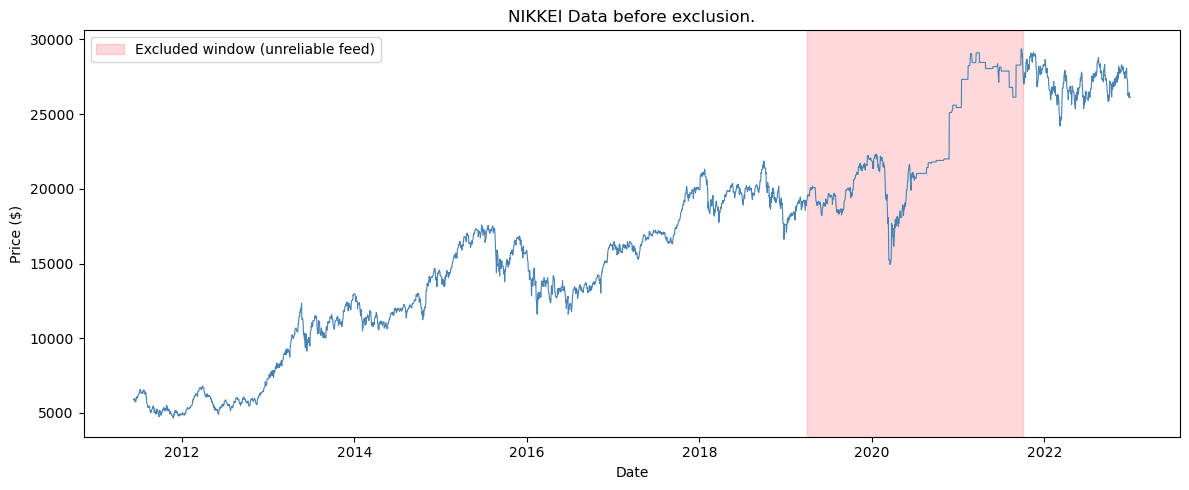

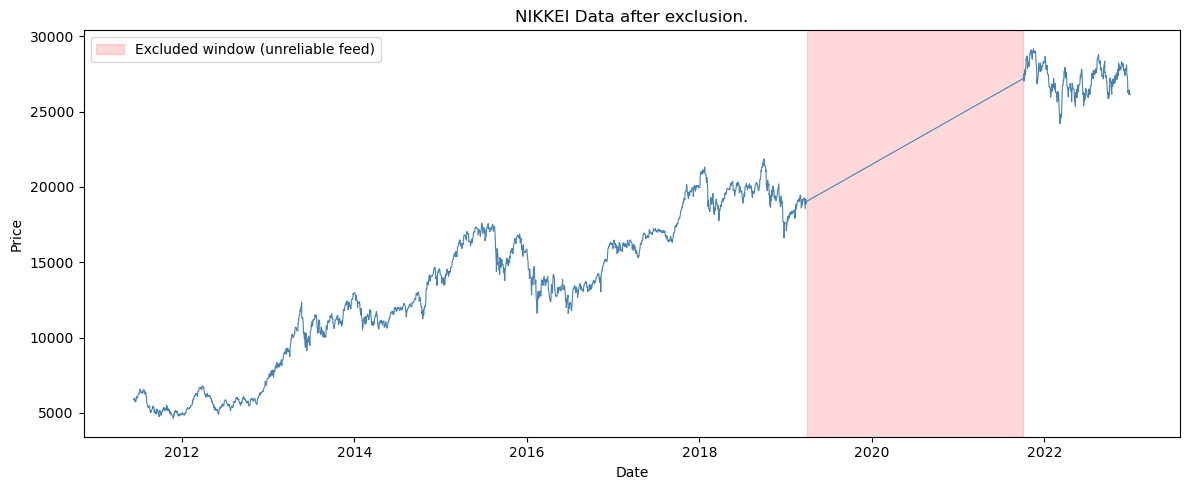

In [30]:
futures_df2 = pd.read_excel("C:/Users/Aksha/OneDrive/Documents/GitHub/systematic-alpha-research/01_data-cleaning/Signal_Project_Data.xlsx", sheet_name = "Data")
futures_df2 = futures_df2.rename(columns={"index":"Date"})

nikkei_1 = futures_df2[["Date","NIKKEI"]].dropna()

plt.figure(figsize=(12,5))
plt.plot(nikkei_1["Date"], nikkei_1["NIKKEI"], linewidth=0.8, color="steelblue")
plt.axvspan(pd.Timestamp("2019-04-01"), pd.Timestamp("2021-10-01"), color="red", alpha=0.15, label="Excluded window (unreliable feed)")
plt.title("NIKKEI Data before exclusion.")
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

nikkei_2 = futures_df[["Date","NIKKEI"]].dropna()

plt.figure(figsize=(12,5))
plt.plot(nikkei_2["Date"], nikkei_2["NIKKEI"], linewidth=0.8, color="steelblue")
plt.axvspan(pd.Timestamp("2019-04-01"), pd.Timestamp("2021-10-01"), color="red", alpha=0.15, label="Excluded window (unreliable feed)")
plt.title("NIKKEI Data after exclusion.")
plt.ylabel("Price")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

## Distributional Analysis on Data:

We will be testing normality using a 5% significance level with 2 degrees of freedom for the Jarque-Bera test, where the critical value is 5.991


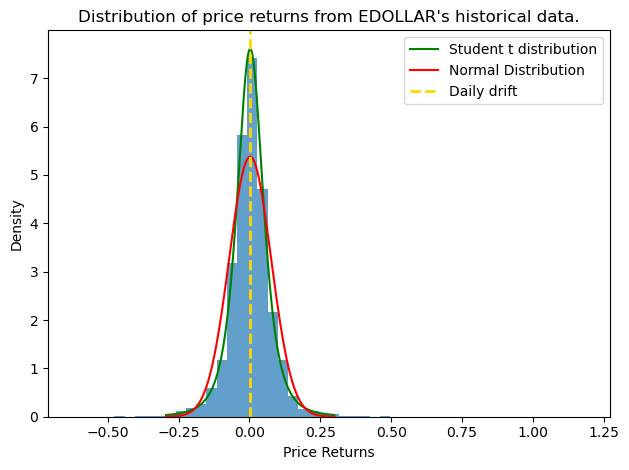

For EDOLLAR, the skew is 0.2183 and the excess kurtosis is 10.4005
The test statistic for EDOLLAR is 45669.90 which is massive compared to 5.991 so we can confidently reject the null hypothesis that the price returns are normally distributed.


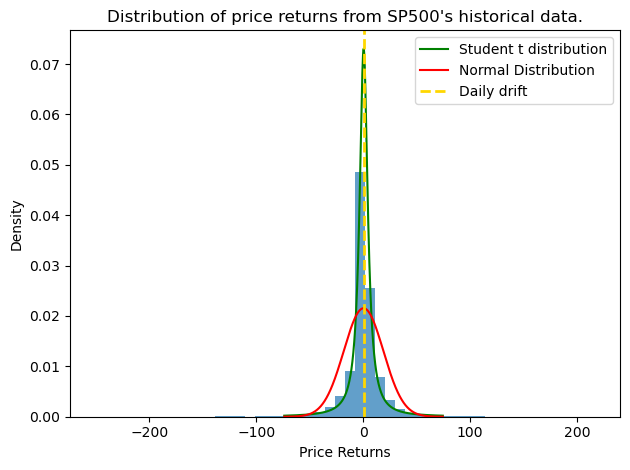

For SP500, the skew is -0.8304 and the excess kurtosis is 21.9151
The test statistic for SP500 is 203577.66 which is massive compared to 5.991 so we can confidently reject the null hypothesis that the price returns are normally distributed.


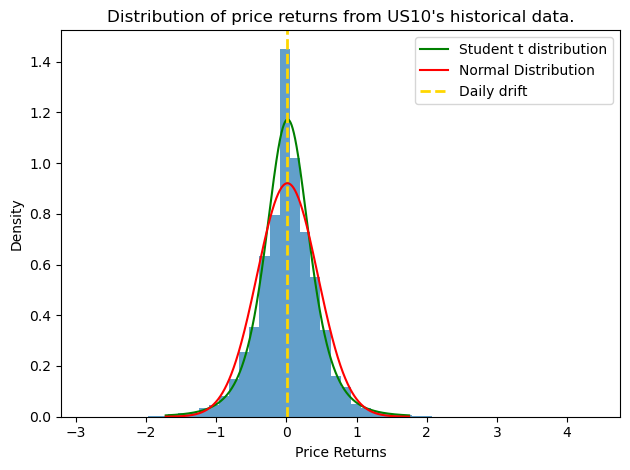

For US10, the skew is 0.1164 and the excess kurtosis is 4.2973
The test statistic for US10 is 7805.95 which is massive compared to 5.991 so we can confidently reject the null hypothesis that the price returns are normally distributed.


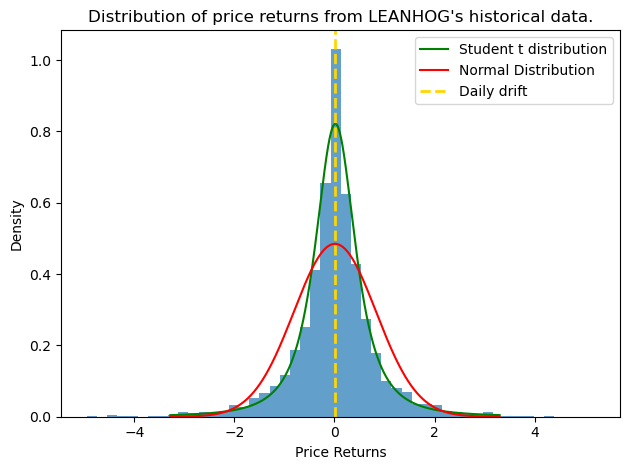

For LEANHOG, the skew is -0.1746 and the excess kurtosis is 4.5396
The test statistic for LEANHOG is 8736.70 which is massive compared to 5.991 so we can confidently reject the null hypothesis that the price returns are normally distributed.


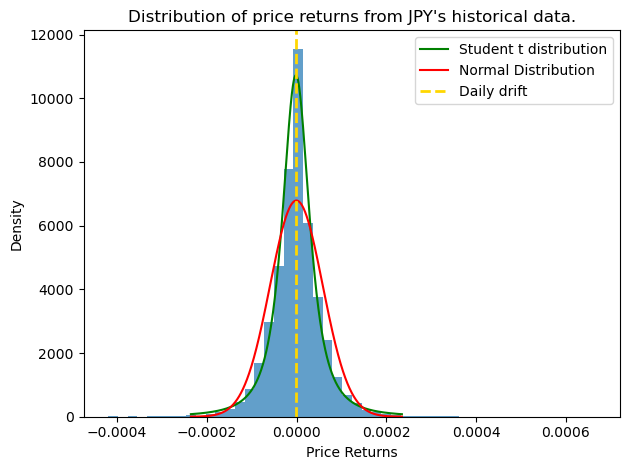

For JPY, the skew is 0.3669 and the excess kurtosis is 7.7743
The test statistic for JPY is 25700.03 which is massive compared to 5.991 so we can confidently reject the null hypothesis that the price returns are normally distributed.


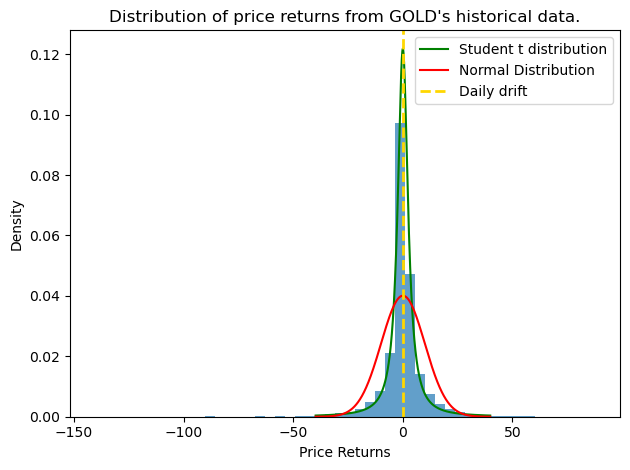

For GOLD, the skew is -0.9270 and the excess kurtosis is 18.7900
The test statistic for GOLD is 150249.66 which is massive compared to 5.991 so we can confidently reject the null hypothesis that the price returns are normally distributed.


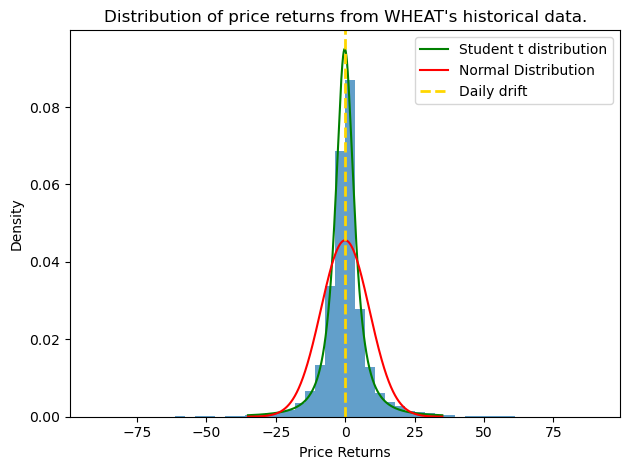

For WHEAT, the skew is -0.0330 and the excess kurtosis is 12.9435
The test statistic for WHEAT is 70610.88 which is massive compared to 5.991 so we can confidently reject the null hypothesis that the price returns are normally distributed.


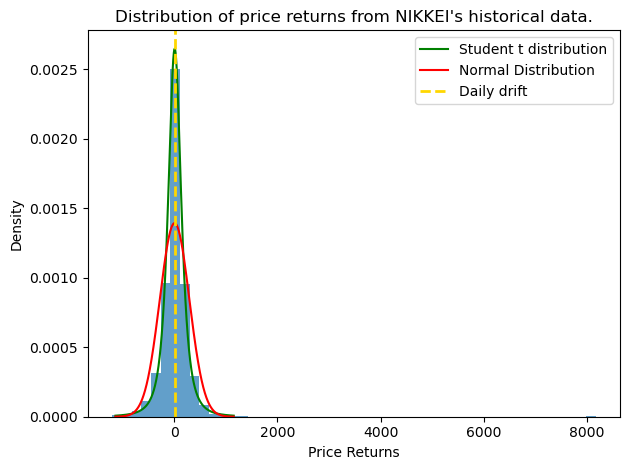

For NIKKEI, the skew is 9.6025 and the excess kurtosis is 279.2316
The test statistic for NIKKEI is 7703344.99 which is massive compared to 5.991 so we can confidently reject the null hypothesis that the price returns are normally distributed.


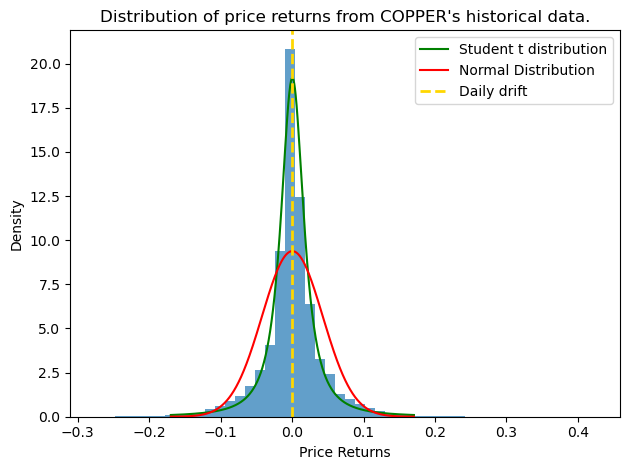

For COPPER, the skew is -0.0580 and the excess kurtosis is 6.4233
The test statistic for COPPER is 12261.19 which is massive compared to 5.991 so we can confidently reject the null hypothesis that the price returns are normally distributed.


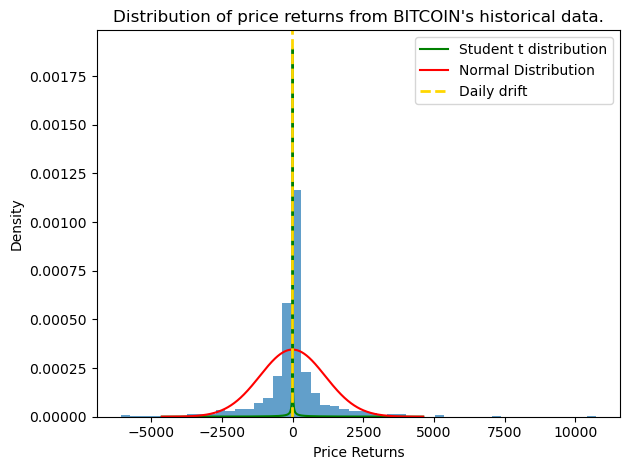

For BITCOIN, the skew is 0.4483 and the excess kurtosis is 12.0046
The test statistic for BITCOIN is 7897.79 which is massive compared to 5.991 so we can confidently reject the null hypothesis that the price returns are normally distributed.


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, t, skew, kurtosis, jarque_bera

print("We will be testing normality using a 5% significance level with 2 degrees of freedom for the Jarque-Bera test, where the critical value is 5.991")

for col in futures_df.columns[1:]:
    s = futures_df[col].dropna()
    price_diffs = s.diff().dropna()
    drift = price_diffs.mean()
    volatility = price_diffs.std()
    df, loc, scale = t.fit(price_diffs)
    x_values = np.linspace(drift - 4*volatility, drift + 4*volatility, 1000)
    plt.plot(x_values, t.pdf(x_values, df, loc, scale), color="green", label = "Student t distribution")
    plt.plot(x_values, norm.pdf(x_values, drift, volatility), color="red", label = "Normal Distribution")
    plt.axvline(x=drift, color="gold", linestyle="--", linewidth=2, label = "Daily drift")
    plt.hist(price_diffs, alpha=0.7, bins=50, density=True)
    plt.title(f"Distribution of price returns from {col}'s historical data.")
    plt.xlabel("Price Returns")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"For {col}, the skew is {skew(price_diffs):.4f} and the excess kurtosis is {kurtosis(price_diffs):.4f}")
    jb_stat, jb_pvalue = jarque_bera(price_diffs)
    print(f"The test statistic for {col} is {jb_stat:.2f} which is massive compared to 5.991 so we can confidently reject the null hypothesis that the price returns are normally distributed.")
    

## Distributional Analysis — Conclusion #1

**Across all ten instruments, daily price differences show strong, 
consistent deviations from normality:**

- **Excess kurtosis** ranged from roughly 4 up to 22, meaning extreme 
  moves occur far more often than a normal distribution would predict 
  for every instrument tested — none behaved close to Gaussian.
- **Skewness** was non-zero and instrument-specific in sign, with 
  equity-like instruments (SP500, GOLD) showing the most pronounced 
  negative skew — consistent with markets that fall sharply but rise 
  more gradually.
- **Jarque-Bera statistics** ranged from roughly 7,000 to over 
  10,000,000 — many orders of magnitude past the ~5.99 critical value 
  at 5% significance (2 degrees of freedom), so normality is rejected 
  decisively for every instrument, not marginally.
- The relative ranking of JB statistics across instruments matched the 
  underlying skew/kurtosis figures, giving confidence the results are 
  internally consistent rather than an artifact of the test.

These findings confirm that financial price differences are fat-tailed 
and not normally distributed, which has two direct implications for 
the rest of this project:

1. **Risk and position sizing cannot assume mild, well-behaved 
   variation** — extreme moves are a structural feature of this data, 
   not noise, and were deliberately retained (see extreme-value check) 
   rather than removed, since a strategy must be tested against real 
   tail risk to be credible.
2. **Volatility itself is not constant** — the strong autocorrelation 
   in absolute price moves indicates volatility clustering, motivating 
   the use of an EWMA-based (exponentially weighted) volatility 
   estimator throughout the signal-construction stage, rather than a 
   single fixed-window standard deviation.

I am now going to explore volatility clustering - standard financial 
models assume constant volatility and the prices move independently 
day to day with no memory. If I find volatility clustering to be true,
this would deny the independence of moves because it shows that periods 
of upwards trends further imply upward trend and vice versa.

In [31]:
# Volatility clustering check: does today's move size predict tomorrow's move size?
lags = [1, 5, 20, 60]

cluster_results = []
for col in futures_df.columns:
    if col == "Date":
        continue
    
    prices = futures_df[col].dropna()
    abs_diffs = prices.diff().dropna().abs()   # size of move, direction ignored
    
    row = {"instrument": col}
    for lag in lags:
        row[f"autocorr_lag{lag}"] = round(abs_diffs.autocorr(lag=lag), 3)
    cluster_results.append(row)

cluster_df = pd.DataFrame(cluster_results)
print(cluster_df.to_string(index=False))

instrument  autocorr_lag1  autocorr_lag5  autocorr_lag20  autocorr_lag60
   EDOLLAR          0.156          0.193           0.153           0.126
     SP500          0.400          0.428           0.365           0.341
      US10          0.094          0.160           0.132           0.096
   LEANHOG          0.272          0.271           0.213           0.194
       JPY          0.162          0.126           0.117           0.091
      GOLD          0.298          0.347           0.314           0.286
     WHEAT          0.362          0.372           0.328           0.265
    NIKKEI          0.088          0.124           0.077           0.064
    COPPER          0.281          0.314           0.293           0.250
   BITCOIN          0.300          0.289           0.351           0.216


**Volatility clustering** — lag-1/5/20/60 autocorrelation of absolute 
price differences was positive for all ten instruments and persisted 
out to 60 days without decaying to zero (e.g. GOLD: 0.298 → 0.286 from 
lag 1 to lag 60). This confirms volatility is not constant over time — 
large moves cluster with large moves, calm periods with calm periods — 
directly motivating an EWMA-style (recency-weighted) volatility 
estimator over a single fixed-window standard deviation.


**Final Summary**
